In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader,TensorDataset

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.drop("id",axis=1,inplace=True)

In [4]:
df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [5]:
df["Sex"] = pd.get_dummies(drop_first=True,data=df["Sex"],dtype="int")

In [6]:
df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,0,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,1,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,0,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,1,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,1,45,182.0,91.0,17.0,102.0,40.3,109.0


In [7]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

scaler_2 = StandardScaler()
y_train = scaler_2.fit_transform(y_train.reshape(-1,1))
y_test = scaler_2.transform(y_test.reshape(-1,1))

In [10]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [11]:
train_dataset = TensorDataset(
    x_train,y_train
)
test_dataset = TensorDataset(
    x_test,y_test
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [13]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=7,out_features=128)
        self.l_norm1 = nn.LayerNorm(128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.1)

        self.fc2 = nn.Linear(128,64)
        self.l_norm2 = nn.LayerNorm(64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)
        
        self.fc3 = nn.Linear(64,32)
        self.l_norm3 = nn.LayerNorm(32)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(32,1)

    def forward(self,x):
        #print("Input",x.shape)
        x = self.fc1(x)
        x = self.l_norm1(x)
        x = self.relu1(x)
        x = self.dropout1(x)


        x = self.fc2(x)
        x = self.l_norm2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.l_norm3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        return x

"""class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.main_nn = nn.Sequential(
            nn.Linear(7,128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(32,1)
        )
    
    def forward(self,x):
        return self.main_nn(x)"""

'class MyModel(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.main_nn = nn.Sequential(\n            nn.Linear(7,128),\n            nn.BatchNorm1d(128),\n            nn.GELU(),\n            nn.Dropout(0.1),\n\n            nn.Linear(128,64),\n            nn.BatchNorm1d(64),\n            nn.GELU(),\n            nn.Dropout(0.1),\n\n            nn.Linear(64,32),\n            nn.BatchNorm1d(32),\n            nn.GELU(),\n            nn.Dropout(0.2),\n\n            nn.Linear(32,1)\n        )\n    \n    def forward(self,x):\n        return self.main_nn(x)'

In [14]:
model = MyModel()

In [15]:
for name,param in model.named_parameters():
    print(name,param.shape)

fc1.weight torch.Size([128, 7])
fc1.bias torch.Size([128])
l_norm1.weight torch.Size([128])
l_norm1.bias torch.Size([128])
fc2.weight torch.Size([64, 128])
fc2.bias torch.Size([64])
l_norm2.weight torch.Size([64])
l_norm2.bias torch.Size([64])
fc3.weight torch.Size([32, 64])
fc3.bias torch.Size([32])
l_norm3.weight torch.Size([32])
l_norm3.bias torch.Size([32])
fc4.weight torch.Size([1, 32])
fc4.bias torch.Size([1])


In [16]:
loss_function = nn.MSELoss()
optmizer_function = torch.optim.AdamW(model.parameters(),
                                      lr=0.001,
                                      weight_decay=0.01)

In [17]:
train_loss_hist = []
test_loss_hist = []

epochs = 50
process_bar = tqdm(range(epochs),colour="green")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_x,batch_y in train_loader:
        optmizer_function.zero_grad()
        prediction = model(batch_x)
        loss = loss_function(prediction,batch_y)
        loss.backward()
        optmizer_function.step()
        total_train_loss += loss.item()

    avg_total_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_x_test,batch_y_test in test_loader:
            val_prediction = model(batch_x_test)
            val_loss = loss_function(val_prediction,batch_y_test)
            total_test_loss += val_loss.item()
    avg_total_test_loss = total_test_loss/len(test_loader)

    train_loss_hist.append(avg_total_train_loss)
    test_loss_hist.append(avg_total_test_loss)

    torch.save({
            "Epochs":epoch,
            "Train Loss":avg_total_train_loss,
            "Test Loss":avg_total_test_loss,
            "Optimizer":optmizer_function.state_dict(),
            "Model":model.state_dict()
        },f"model_2/checkpoints_{epoch}.pth")

    process_bar.set_postfix({
            "Epoch":epoch,
            "Train Loss":f"{avg_total_train_loss:.4f}",
            "Test Loss":f"{avg_total_test_loss:.4f}"
        })

100%|██████████| 50/50 [11:27<00:00, 13.76s/it, Epoch=49, Train Loss=0.0212, Test Loss=0.0049]


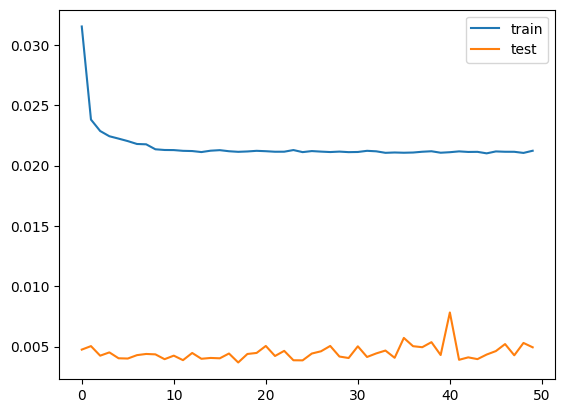

In [19]:
plt.plot(train_loss_hist,label="train")
plt.plot(test_loss_hist,label="test")
plt.legend()

# Advance Training with (GELU)

In [17]:
train_loss_hist = []
test_loss_hist = []

epochs = 50

process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optmizer_function.zero_grad()
        prediction = model(batch_train_x)
        loss = loss_function(prediction,batch_train_y)
        loss.backward()
        optmizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_test_x,batch_test_y in test_loader:
            val_prediction = model(batch_test_x)
            val_loss = loss_function(val_prediction,batch_test_y)
            total_test_loss += val_loss.item()
    avg_total_test_loss = total_test_loss / len(test_loader)

    train_loss_hist.append(avg_train_loss)
    test_loss_hist.append(avg_total_test_loss)

    torch.save({
        "Epochs":epoch,
        "Train Loss":avg_train_loss,
        "Test Loss":avg_total_test_loss,
        "optmizer_function":optmizer_function.state_dict(),
        "Model":model.state_dict()
    },f"model_3/checkpoint_{epoch}.pth")

    process_bar.set_postfix({
        "Epoch":epoch+1,
        "Train Loss":avg_train_loss,
        "Test Loss":avg_total_test_loss
    })

100%|██████████| 50/50 [14:53<00:00, 17.86s/it, Epoch=50, Train Loss=0.0246, Test Loss=0.00534]


In [18]:
import matplotlib.pyplot as plt

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


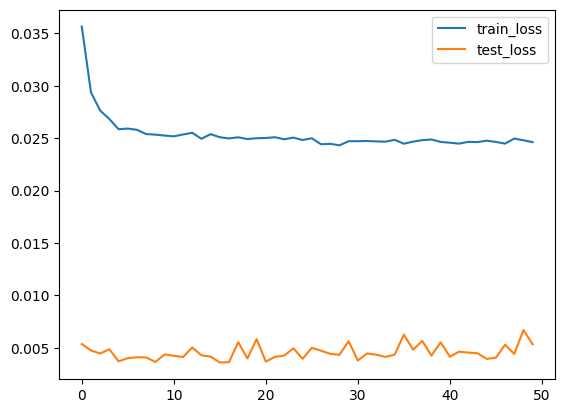

In [20]:
plt.plot(train_loss_hist,label="train_loss")
plt.plot(test_loss_hist,label="test_loss")
plt.legend()